<a href="https://colab.research.google.com/github/k4urman/xternchallenge2026/blob/main/MISO_Data_Center_Capacity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Data center capacity in the MISO footprint
# Source: datacenter.fyi, pulled 10 Sep 2026
# ============================================================
# Upload MISO_Data_Center_Capacity.xlsx to Drive first.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

PATH = '/content/drive/MyDrive/MISO_Data_Center_Capacity.xlsx'
dc = pd.read_excel(PATH, sheet_name='Raw Data')
dc.columns = [c.strip() for c in dc.columns]
print(dc.shape)
dc.head()

Mounted at /content/drive
(187, 9)


,State,Project Name,Developer,City,Grid Operator,RTO,In MISO?,Capacity (MW),Status
0,AR,Walmart,Walmart,Bentonville,El Paso Electric (source error),Source error - not this utility,No,12.884,Operational
1,IA,Google Cedar Rapids,(not provided),Cedar Rapids,Interstate Power and Light,MISO,Yes,NaN,Construction
2,IA,QTS Cedar Rapids,(not provided),Cedar Rapids,Interstate Power and Light,MISO,Yes,NaN,Construction
3,IA,Apple,Apple,Waukee,MidAmerican Energy,MISO,Yes,NaN,Operational
4,IA,Cast & Crew,TEAM Companies,Waukee,MidAmerican Energy,MISO,Yes,2.250,Operational


In [12]:
q = pd.read_csv('/content/drive/MyDrive/GI Interactive Queue (1)(in).csv')
q.columns = [c.strip() for c in q.columns]

for c in ['Queue Date', 'Withdrawn Date', 'Done Date']:
    q[c] = pd.to_datetime(q[c], errors='coerce')

q['OUTCOME'] = 'Active'
q.loc[q['Withdrawn Date'].notna(), 'OUTCOME'] = 'Withdrawn'
q.loc[q['Done Date'].notna(), 'OUTCOME'] = 'Built'
q['SUMMER_MW'] = pd.to_numeric(q['Summer MW'], errors='coerce')

df_act = q[q['OUTCOME'] == 'Active'].copy()
df_res = q[q['OUTCOME'] != 'Active'].copy()

print(q['OUTCOME'].value_counts())
print('active MW:', round(df_act['SUMMER_MW'].sum()))

OUTCOME
Withdrawn    2084
Active       1469
Built         269
Name: count, dtype: int64
active MW: 300293


          PROJECTS       MW
In MISO?                   
No              82   7025.0
Yes            105  12220.0


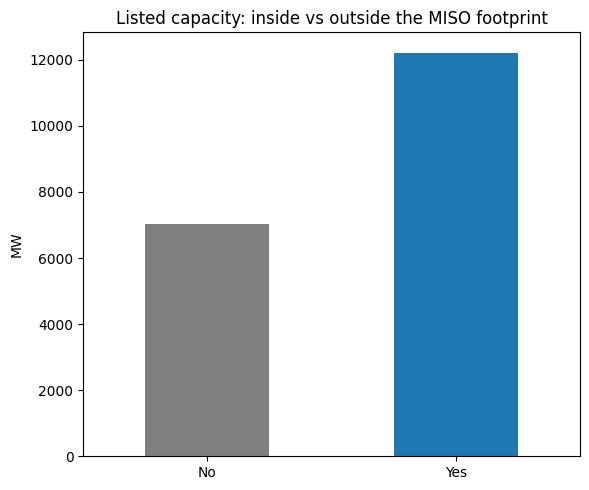

In [2]:
# ============================================================
# Q1 How much of this data is actually in MISO?
# ============================================================
# The site organizes by state. MISO does not follow state lines.
# Every row is classified by its utility, not its state.

Split1 = dc.groupby('In MISO?').agg(
    PROJECTS=('Capacity (MW)', 'size'),
    MW=('Capacity (MW)', 'sum'),
).round(0)
print(Split1)

ax = Split1['MW'].plot(kind='bar', color=['tab:gray', 'tab:blue'], figsize=(6, 5))
ax.set_ylabel('MW')
ax.set_xlabel('')
ax.set_title('Listed capacity: inside vs outside the MISO footprint')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [3]:
# ---- which RTOs the non-MISO rows actually belong to ----
print(dc[dc['In MISO?'] == 'No']
      .groupby('RTO')['Capacity (MW)']
      .agg(['size', 'sum']).round(0)
      .sort_values('sum', ascending=False))


                                 size     sum
RTO                                          
PJM                                70  6789.0
PJM (Ohio coop)                     1   132.0
SPP / mixed                         1    47.0
SPP                                 8    39.0
Source error - not this utility     2    19.0


Status  Operational  Construction  Proposed  Cancelled    LIVE
State                                                         
LA              0.0           0.0       0.0        0.0     0.0
SD              2.0           0.0       0.0        0.0     2.0
IL              4.0           0.0       0.0        0.0     4.0
MO             13.0           0.0       0.0        0.0    13.0
MN             27.0           0.0       9.0        0.0    37.0
MT             40.0           0.0       0.0        0.0    40.0
MI             62.0           0.0       0.0        0.0    62.0
WI             65.0           0.0       0.0        0.0    65.0
MS            352.0           0.0     477.0        0.0   829.0
IA            757.0           0.0     164.0        0.0   921.0
IN            243.0        1947.0    5176.0     2880.0  7367.0


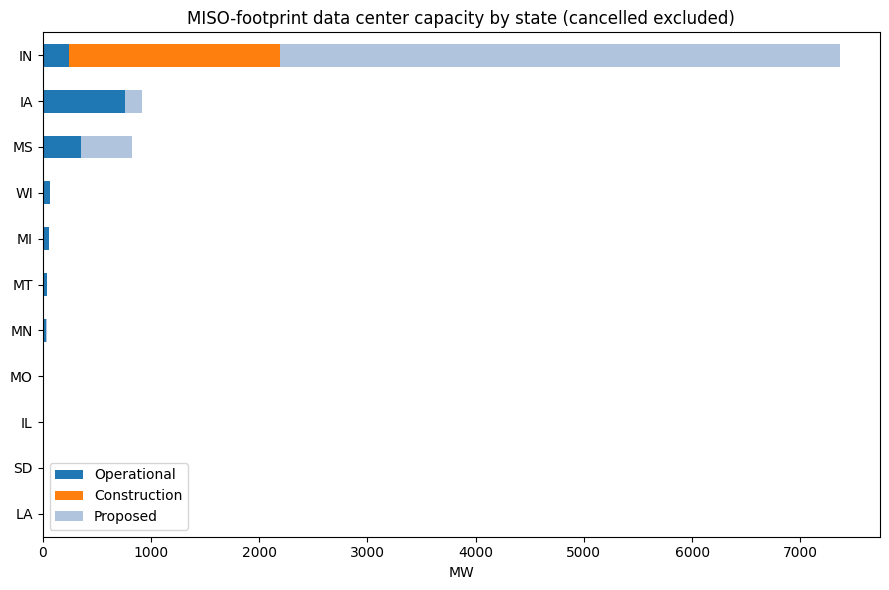

In [4]:
# ============================================================
# Q2 MISO capacity by state and status
# ============================================================
miso = dc[dc['In MISO?'] == 'Yes'].copy()

Pivot2 = (miso.pivot_table(index='State', columns='Status',
                           values='Capacity (MW)', aggfunc='sum')
              .fillna(0))

# put the columns in a sensible order and drop cancelled from the stack
ORDER = [c for c in ['Operational', 'Construction', 'Proposed'] if c in Pivot2]
Pivot2 = Pivot2[ORDER + [c for c in Pivot2.columns if c not in ORDER]]
Pivot2['LIVE'] = Pivot2[ORDER].sum(axis=1)
Pivot2 = Pivot2.sort_values('LIVE', ascending=True)
print(Pivot2.round(0))

ax = Pivot2[ORDER].plot(kind='barh', stacked=True, figsize=(9, 6),
                        color=['tab:blue', 'tab:orange', 'lightsteelblue'])
ax.set_xlabel('MW')
ax.set_ylabel('')
ax.set_title('MISO-footprint data center capacity by state '
             '(cancelled excluded)')
ax.legend(title='')
plt.tight_layout()
plt.show()

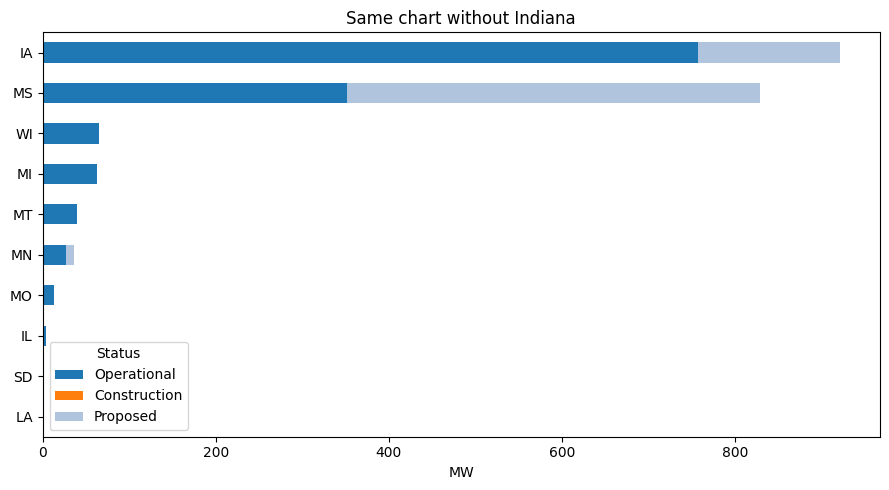

In [5]:
# ---- Indiana dominates. Show it without Indiana too. ----
NoIN = Pivot2.drop('IN', errors='ignore')
ax = NoIN[ORDER].plot(kind='barh', stacked=True, figsize=(9, 5),
                      color=['tab:blue', 'tab:orange', 'lightsteelblue'])
ax.set_xlabel('MW')
ax.set_ylabel('')
ax.set_title('Same chart without Indiana')
plt.tight_layout()
plt.show()


In [6]:
# ============================================================
# Q3 How much of this is real vs intent?
# ============================================================
# Operational and Construction are here or coming.
# Proposed is intent. Cancelled already died.

Stage3 = miso.groupby('Status')['Capacity (MW)'].agg(['size', 'sum']).round(0)
Stage3.columns = ['PROJECTS', 'MW']
Stage3 = Stage3.reindex(['Operational', 'Construction', 'Proposed', 'Cancelled'])
print(Stage3)

here = Stage3.loc[['Operational', 'Construction'], 'MW'].sum()
intent = Stage3.loc['Proposed', 'MW']
dead = Stage3.loc['Cancelled', 'MW']

print(f'\nhere or coming: {here:,.0f} MW')
print(f'proposed only:  {intent:,.0f} MW')
print(f'already dead:   {dead:,.0f} MW')
print(f'cancellation rate so far: '
      f'{dead / (dead + here + intent):.1%} of all listed MW')


              PROJECTS      MW
Status                        
Operational         51  1567.0
Construction         9  1947.0
Proposed            32  5827.0
Cancelled           13  2880.0

here or coming: 3,514 MW
proposed only:  5,827 MW
already dead:   2,880 MW
cancellation rate so far: 23.6% of all listed MW


In [7]:
# ============================================================
# Q4 The disclosure problem
# ============================================================
# Rows with no capacity count as zero. Every total above is a floor.

miso['HAS_MW'] = miso['Capacity (MW)'].notna()
Disc4 = miso.groupby('Status')['HAS_MW'].agg(['size', 'sum'])
Disc4.columns = ['PROJECTS', 'WITH_CAPACITY']
Disc4['BLANK'] = Disc4['PROJECTS'] - Disc4['WITH_CAPACITY']
Disc4['PCT_DISCLOSED'] = (Disc4['WITH_CAPACITY'] / Disc4['PROJECTS'] * 100).round(0)
print(Disc4)

print('\nMISO projects with no capacity listed:')
print(miso[~miso['HAS_MW']][['State', 'Project Name', 'Status']]
      .to_string(index=False))



              PROJECTS  WITH_CAPACITY  BLANK  PCT_DISCLOSED
Status                                                     
Cancelled           13              4      9           31.0
Construction         9              2      7           22.0
Operational         51             46      5           90.0
Proposed            32             16     16           50.0

MISO projects with no capacity listed:
State                         Project Name       Status
   IA                  Google Cedar Rapids Construction
   IA                     QTS Cedar Rapids Construction
   IA                                Apple  Operational
   IN               Agincourt - Valparaiso    Cancelled
   IN Digital Resources Acq. - Elletsville    Cancelled
   IN                  Prologis - Leesburg    Cancelled
   IN      Provident Realty - Burns Harbor    Cancelled
   IN        Provident Realty - Chesterton    Cancelled
   IN             Province Group - Bristol    Cancelled
   IN                     QTS - Jeremiah

Project Name
Meta - Lebanon                1540.0
Takanock - Goshen             1500.0
Google - Monrovia             1200.0
Amazon                         820.0
Microsoft - LaPorte            538.0
Sentinel - Hebron              504.0
Microsoft                      469.0
Meta - Jeffersonville          407.0
Unnamed - Brazil               400.0
Amazon Madison Mega Site       341.0
Unnamed - Marble Hill          310.0
Sabey Corp. - Indianapolis     250.0
Name: Capacity (MW), dtype: float64


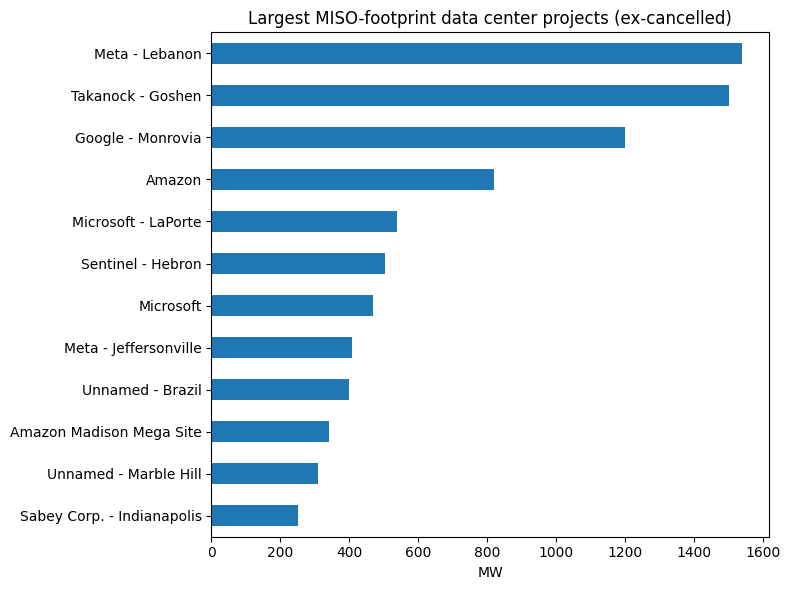

In [8]:
# ============================================================
# Q5 Who is building it
# ============================================================
Dev5 = (miso[miso['Status'] != 'Cancelled']
        .groupby('Project Name')['Capacity (MW)'].sum()
        .sort_values(ascending=False).head(12))
print(Dev5.round(0))

ax = Dev5.sort_values().plot(kind='barh', figsize=(8, 6), color='tab:blue')
ax.set_xlabel('MW')
ax.set_ylabel('')
ax.set_title('Largest MISO-footprint data center projects (ex-cancelled)')
plt.tight_layout()
plt.show()

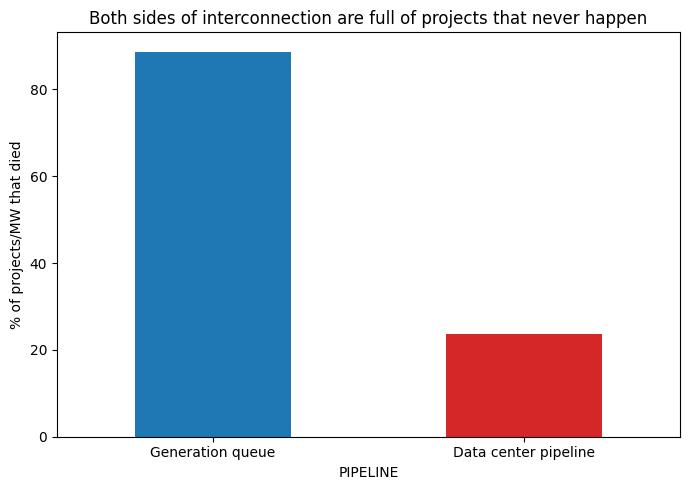

In [9]:
Att = pd.DataFrame({
    'PIPELINE': ['Generation queue', 'Data center pipeline'],
    'DEAD_PCT': [88.7, 2880 / 12220 * 100],
})
ax = Att.plot(kind='bar', x='PIPELINE', y='DEAD_PCT', legend=False,
              color=['tab:blue', 'tab:red'], figsize=(7, 5))
ax.set_ylabel('% of projects/MW that died')
ax.set_title('Both sides of interconnection are full of projects that never happen')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
IN_dc = miso[miso['State'] == 'IN']
IN_gen = df_act[df_act['State'] == 'IN']   # from the queue notebook

print('Indiana data center MW, live:',
      IN_dc[IN_dc['Status'].isin(['Operational','Construction'])]['Capacity (MW)'].sum())
print('Indiana data center MW, proposed:',
      IN_dc[IN_dc['Status']=='Proposed']['Capacity (MW)'].sum())
print('Indiana data center MW, cancelled:',
      IN_dc[IN_dc['Status']=='Cancelled']['Capacity (MW)'].sum())
print('Indiana generation queue MW:', IN_gen['SUMMER_MW'].sum())
print('Indiana risk-adjusted:', IN_gen['SUMMER_MW'].sum() * 0.113)

Indiana data center MW, live: 2190.134
Indiana data center MW, proposed: 5176.457
Indiana data center MW, cancelled: 2880.0
Indiana generation queue MW: 28520.9
Indiana risk-adjusted: 3222.8617000000004


In [14]:
# ============================================================
# 3D map: MISO-footprint data center capacity by city
# ============================================================
!pip install pydeck -q

import pydeck as pdk
import pandas as pd
import numpy as np

# City coordinates for every MISO city in the dataset.
# The two "(not provided)" rows are approximated to the known
# project areas - flagged in the tooltip.
CITY = {
 ('IA','Altoona'):(41.644,-93.464), ('IA','Cedar Rapids'):(41.978,-91.665),
 ('IA','Council Bluffs'):(41.262,-95.861), ('IA','Monticello'):(42.236,-91.186),
 ('IA','Waukee'):(41.607,-93.886), ('IA','West Des Moines'):(41.577,-93.711),
 ('IL','Moline'):(41.506,-90.515),
 ('IN','Auburn'):(41.367,-85.059), ('IN','Brazil'):(39.523,-87.125),
 ('IN','Bristol'):(41.719,-85.818), ('IN','Burns Harbor'):(41.626,-87.129),
 ('IN','Chesterton'):(41.610,-87.053), ('IN','Dale'):(38.169,-86.989),
 ('IN','Elletsville'):(39.234,-86.625), ('IN','Frankfort'):(40.279,-86.511),
 ('IN','Gary'):(41.593,-87.346), ('IN','Goshen'):(41.582,-85.834),
 ('IN','Greenfield'):(39.785,-85.769), ('IN','Greensburg'):(39.337,-85.483),
 ('IN','Hammond'):(41.583,-87.500), ('IN','Hanover'):(38.712,-85.472),
 ('IN','Hebron'):(41.317,-87.201), ('IN','Hobart'):(41.532,-87.254),
 ('IN','Indianapolis'):(39.768,-86.158), ('IN','Jeffersonville'):(38.277,-85.736),
 ('IN','Kingbury'):(41.529,-86.694), ('IN','Knightstown'):(39.795,-85.526),
 ('IN','Knox'):(41.296,-86.625), ('IN','LaPorte'):(41.611,-86.723),
 ('IN','Lebanon'):(40.048,-86.469), ('IN','Leesburg'):(41.330,-85.855),
 ('IN','McCordsville'):(39.888,-85.923), ('IN','Merom'):(39.064,-87.567),
 ('IN','Merrillville'):(41.483,-87.333), ('IN','Michigan City'):(41.708,-86.895),
 ('IN','Monrovia'):(39.579,-86.481), ('IN','New Carlisle'):(41.700,-86.510),
 ('IN','Pittsboro'):(39.865,-86.466), ('IN','Portage'):(41.576,-87.176),
 ('IN','Valparaiso'):(41.473,-87.061), ('IN','Wheatfield'):(41.191,-87.052),
 ('IN','Wheeler'):(41.472,-87.152), ('IN','Wolcutt'):(40.757,-87.043),
 ('LA','Slidell'):(30.275,-89.781),
 ('LA','(not provided)'):(32.420,-91.770),   # Meta Hyperion, Richland Parish
 ('MI','Auburn Hills'):(42.687,-83.234), ('MI','Caledonia'):(42.790,-85.518),
 ('MI','Pontiac'):(42.639,-83.291), ('MI','Troy'):(42.606,-83.150),
 ('MN','Brooklyn Park'):(45.094,-93.356), ('MN','Elk River'):(45.304,-93.567),
 ('MN','Hopkins'):(44.925,-93.463), ('MN','Maple Grove'):(45.073,-93.456),
 ('MN','Mendota Heights'):(44.884,-93.140), ('MN','Minneapolis'):(44.978,-93.265),
 ('MO','Hazelwood'):(38.771,-90.371), ('MO','St. Louis'):(38.627,-90.199),
 ('MS','Canton'):(32.612,-90.037), ('MS','Kiln'):(30.406,-89.427),
 ('MS','Ridgeland'):(32.428,-90.132),
 ('MT','(not provided)'):(47.717,-104.157),  # Crusoe, Bakken / eastern MT
 ('SD','Garretson'):(43.717,-96.503),
 ('WI','Brown Deer'):(43.163,-87.963), ('WI','Franklin'):(42.889,-88.005),
 ('WI','Mt. Pleasant'):(42.719,-87.878),
}

APPROX = [('LA','(not provided)'), ('MT','(not provided)')]


# ---- aggregate to city level, split by status ----
m = dc[dc['In MISO?'] == 'Yes'].copy()
m['Capacity (MW)'] = m['Capacity (MW)'].fillna(0)

Map = (m.pivot_table(index=['State','City'], columns='Status',
                     values='Capacity (MW)', aggfunc='sum')
         .fillna(0).reset_index())
for col in ['Operational','Construction','Proposed','Cancelled']:
    if col not in Map:
        Map[col] = 0.0

Map['PROJECTS'] = m.groupby(['State','City']).size().values
Map['LIVE'] = Map['Operational'] + Map['Construction']
Map['TOTAL'] = Map['LIVE'] + Map['Proposed']

Map['LAT'] = [CITY.get((s, c), (None, None))[0]
              for s, c in zip(Map['State'], Map['City'])]
Map['LON'] = [CITY.get((s, c), (None, None))[1]
              for s, c in zip(Map['State'], Map['City'])]
Map['APPROX'] = [' (location approx.)' if (s, c) in APPROX else ''
                 for s, c in zip(Map['State'], Map['City'])]

missing = Map[Map['LAT'].isna()]
if len(missing):
    print('NO COORDS for:', missing[['State','City']].values.tolist())
Map = Map.dropna(subset=['LAT'])

Map['LABEL'] = Map['City'] + ', ' + Map['State'] + Map['APPROX']
print(Map.sort_values('TOTAL', ascending=False)
        [['LABEL','LIVE','Proposed','Cancelled','TOTAL']].head(15).round(0))


# ---- split into three layers ----
Has = Map[Map['TOTAL'] > 0].copy()          # columns
None_ = Map[Map['TOTAL'] == 0].copy()       # flat dots: no capacity disclosed
Dead = Map[Map['Cancelled'] > 0].copy()     # gray ghost columns

# log height, since Merom at 1,580 MW would flatten a 0.2 MW site
V = np.log1p(Has['TOTAL'])
Has['NORM'] = (V - V.min()) / (V.max() - V.min())
Has['HEIGHT'] = (Has['NORM'] * 0.9 + 0.10) * 260_000

Vd = np.log1p(Dead['Cancelled'])
Dead['HEIGHT'] = ((Vd - Vd.min()) / max(Vd.max() - Vd.min(), 1) * 0.9 + 0.10) * 260_000

# color by how much of the capacity is only proposed
# blue = built or building, orange = mostly still on paper
Has['P_SHARE'] = Has['Proposed'] / Has['TOTAL']

def ramp(t, alpha=225):
    stops = [(0.0,(40,110,220)), (0.5,(150,80,190)), (1.0,(255,150,50))]
    for (p0,c0),(p1,c1) in zip(stops, stops[1:]):
        if t <= p1:
            f = (t-p0)/(p1-p0)
            return [int(a+(b-a)*f) for a,b in zip(c0,c1)] + [alpha]
    return list(stops[-1][1]) + [alpha]

Has['COLOR'] = Has['P_SHARE'].map(ramp)


layers = [
    pdk.Layer('ScatterplotLayer', data=None_,
              get_position=['LON','LAT'], get_radius=9_000,
              get_fill_color=[120,130,150,150], stroked=False),
    pdk.Layer('ColumnLayer', data=Dead,
              get_position=['LON','LAT'], get_elevation='HEIGHT',
              radius=9_000, get_fill_color=[110,110,120,90],
              disk_resolution=20, extruded=True),
    pdk.Layer('ColumnLayer', data=Has,
              get_position=['LON','LAT'], get_elevation='HEIGHT',
              radius=13_000, get_fill_color='COLOR',
              disk_resolution=32, extruded=True,
              pickable=True, auto_highlight=True),
]

deck = pdk.Deck(
    layers=layers,
    initial_view_state=pdk.ViewState(latitude=39.5, longitude=-88.5,
                                     zoom=4.5, pitch=55, bearing=-15),
    map_style='dark',
    tooltip={'text': '{LABEL}\n{PROJECTS} projects\n'
                     'Live: {LIVE} MW\nProposed: {Proposed} MW\n'
                     'Cancelled: {Cancelled} MW'},
)

deck.to_html('miso_dc_map.html')
deck

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.0 MB/s eta 0:00:00
Status                LABEL    LIVE  Proposed  Cancelled   TOTAL
29              Lebanon, IN  1540.0       0.0        0.0  1540.0
16               Goshen, IN     0.0    1500.0        0.0  1500.0
35             Monrovia, IN     0.0    1200.0        0.0  1200.0
57               Canton, MS   341.0     477.0        0.0   818.0
28              LaPorte, IN     0.0     538.0        0.0   538.0
21               Hebron, IN     0.0     504.0        0.0   504.0
5       West Des Moines, IA   411.0       0.0        0.0   411.0
24       Jeffersonville, IN   407.0       3.0        0.0   410.0
8                Brazil, IN     0.0     400.0        0.0   400.0
2        Council Bluffs, IA   344.0       0.0        0.0   344.0
23         Indianapolis, IN     1.0     332.0      400.0   332.0
36         New Carlisle, IN     0.0     322.0        0.0   322.0
20              Hanover, IN     0.0     310.0        0.0   310.0
19         

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{
  "initialViewState": {
    "bearing": -15,
    "latitude": 39.5,
    "longitude": -88.5,
    "pitch": 55,
    "zoom": 4.5
  },
  "layers": [
    {
      "@@type": "ScatterplotLayer",
      "data": [
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Cedar Rapids",
          "Construction": 0.0,
          "LABEL": "Cedar Rapids, IA",
          "LAT": 41.978,
          "LIVE": 0.0,
          "LON": -91.665,
          "Operational": 0.0,
          "PROJECTS": 2,
          "Proposed": 0.0,
          "State": "IA",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Bristol",
          "Construction": 0.0,
          "LABEL": "Bristol, IN",
          "LAT": 41.719,
          "LIVE": 0.0,
          "LON": -85.818,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Burns Harbor",
          "Construction": 0.0,
          "LABEL": "Burns Harbor, IN",
          "LAT": 41.626,
          "LIVE": 0.0,
          "LON": -87.129,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Chesterton",
          "Construction": 0.0,
          "LABEL": "Chesterton, IN",
          "LAT": 41.61,
          "LIVE": 0.0,
          "LON": -87.053,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Dale",
          "Construction": 0.0,
          "LABEL": "Dale, IN",
          "LAT": 38.169,
          "LIVE": 0.0,
          "LON": -86.989,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Elletsville",
          "Construction": 0.0,
          "LABEL": "Elletsville, IN",
          "LAT": 39.234,
          "LIVE": 0.0,
          "LON": -86.625,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 300.0,
          "City": "Frankfort",
          "Construction": 0.0,
          "LABEL": "Frankfort, IN",
          "LAT": 40.279,
          "LIVE": 0.0,
          "LON": -86.511,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Gary",
          "Construction": 0.0,
          "LABEL": "Gary, IN",
          "LAT": 41.593,
          "LIVE": 0.0,
          "LON": -87.346,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Greenfield",
          "Construction": 0.0,
          "LABEL": "Greenfield, IN",
          "LAT": 39.785,
          "LIVE": 0.0,
          "LON": -85.769,
          "Operational": 0.0,
          "PROJECTS": 1,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 0.0,
          "City": "Hobart",
          "Construction": 0.0,
          "LABEL": "Hobart, IN",
          "LAT": 41.532,
          "LIVE": 0.0,
          "LON": -87.254,
          "Operational": 0.0,
          "PROJECTS": 2,
          "Proposed": 0.0,
          "State": "IN",
          "TOTAL": 0.0
        },
        {
          "APPROX": "",
          "Cancelled": 

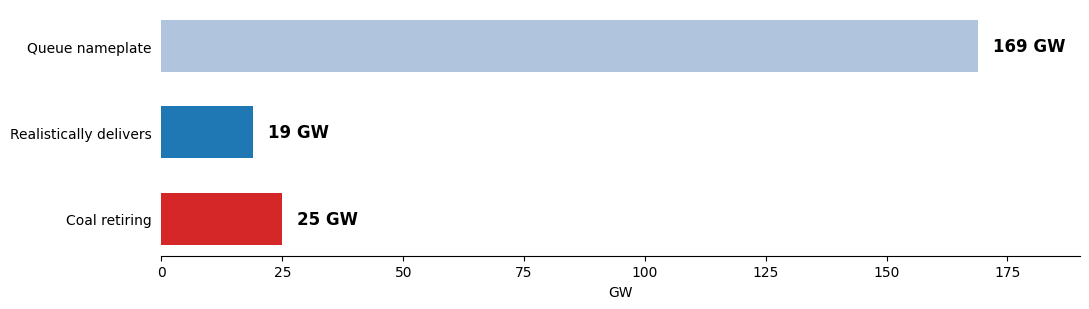

In [15]:
import matplotlib.pyplot as plt

labels = ['Queue nameplate', 'Realistically delivers', 'Coal retiring']
vals   = [169, 19, 25]
colors = ['lightsteelblue', 'tab:blue', 'tab:red']

fig, ax = plt.subplots(figsize=(11, 3.2))
bars = ax.barh(labels, vals, color=colors, height=0.6)
for b, v in zip(bars, vals):
    ax.text(v + 3, b.get_y() + b.get_height()/2, f'{v} GW',
            va='center', fontsize=12, fontweight='bold')
ax.set_xlim(0, 190)
ax.invert_yaxis()
ax.set_xlabel('GW')
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig('slide3_chart.png', dpi=220, bbox_inches='tight')
plt.show()

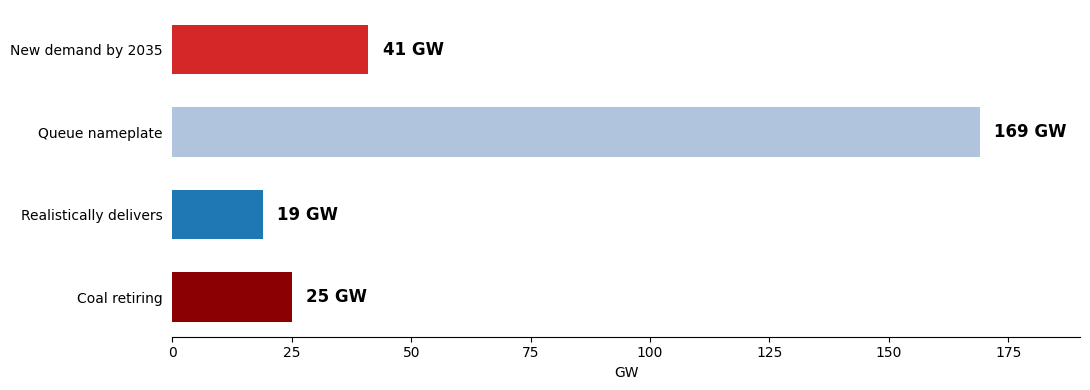

In [16]:
labels = ['New demand by 2035', 'Queue nameplate',
          'Realistically delivers', 'Coal retiring']
vals   = [41, 169, 19, 25]
colors = ['tab:red', 'lightsteelblue', 'tab:blue', 'darkred']

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(labels, vals, color=colors, height=0.6)
for b, v in zip(bars, vals):
    ax.text(v + 3, b.get_y() + b.get_height()/2, f'{v} GW',
            va='center', fontsize=12, fontweight='bold')
ax.set_xlim(0, 190)
ax.invert_yaxis()
ax.set_xlabel('GW')
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

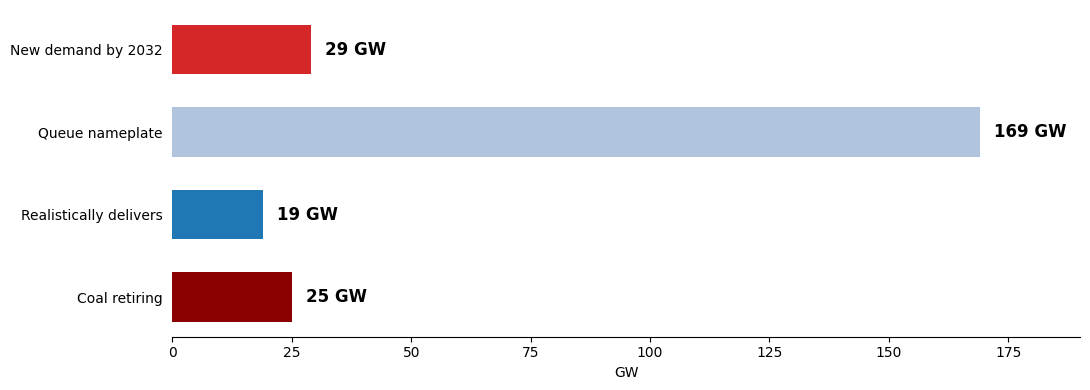

In [17]:
labels = ['New demand by 2032', 'Queue nameplate',
          'Realistically delivers', 'Coal retiring']
vals   = [29, 169, 19, 25]
colors = ['tab:red', 'lightsteelblue', 'tab:blue', 'darkred']

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(labels, vals, color=colors, height=0.6)
for b, v in zip(bars, vals):
    ax.text(v + 3, b.get_y() + b.get_height()/2, f'{v} GW',
            va='center', fontsize=12, fontweight='bold')
ax.set_xlim(0, 190)
ax.invert_yaxis()
ax.set_xlabel('GW')
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

In [18]:
print(df_act['Appl In Service Date'].dt.year.value_counts().sort_index())
print()
print('MW by claimed in-service year:')
print(df_act.groupby(df_act['Appl In Service Date'].dt.year)['SUMMER_MW']
      .sum().round(0))
print()
print('MW with in-service date after 2032:',
      round(df_act[df_act['Appl In Service Date'].dt.year > 2032]['SUMMER_MW'].sum()))
print('MW with no in-service date:',
      round(df_act[df_act['Appl In Service Date'].isna()]['SUMMER_MW'].sum()))

AttributeError: Can only use .dt accessor with datetimelike values

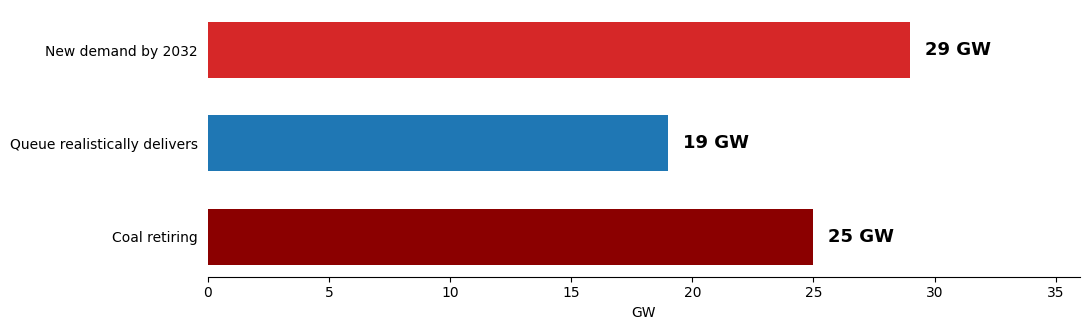

In [19]:

import matplotlib.pyplot as plt

labels = ['New demand by 2032', 'Queue realistically delivers', 'Coal retiring']
vals   = [29, 19, 25]
colors = ['tab:red', 'tab:blue', 'darkred']

fig, ax = plt.subplots(figsize=(11, 3.4))
bars = ax.barh(labels, vals, color=colors, height=0.6)
for b, v in zip(bars, vals):
    ax.text(v + 0.6, b.get_y() + b.get_height()/2, f'{v} GW',
            va='center', fontsize=13, fontweight='bold')
ax.set_xlim(0, 36)
ax.invert_yaxis()
ax.set_xlabel('GW')
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig('slide3_chart.png', dpi=220, bbox_inches='tight')
plt.show()


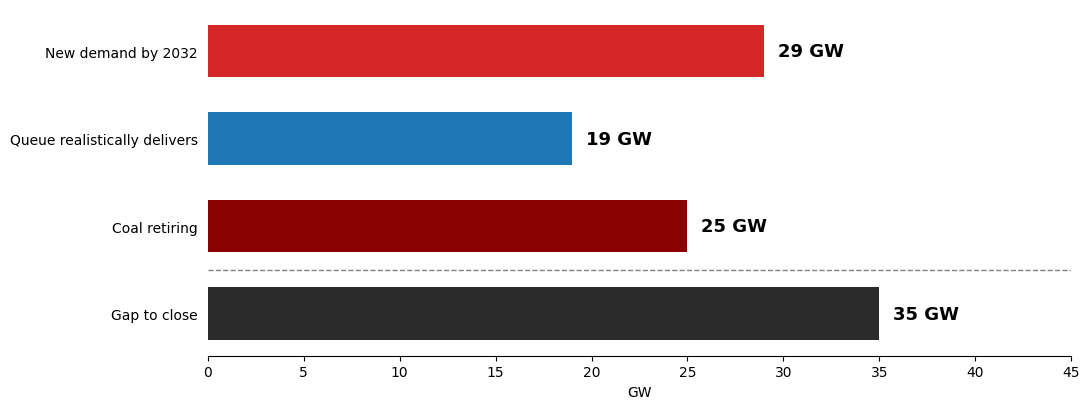

In [20]:

import matplotlib.pyplot as plt

DEMAND, DELIVERS, RETIRE = 29, 19, 25
GAP = DEMAND + (RETIRE - DELIVERS)          # 29 + 6 = 35

labels = ['New demand by 2032',
          'Queue realistically delivers',
          'Coal retiring',
          'Gap to close']
vals   = [DEMAND, DELIVERS, RETIRE, GAP]
colors = ['tab:red', 'tab:blue', 'darkred', '#2b2b2b']

fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.barh(labels, vals, color=colors, height=0.6)

for b, v in zip(bars, vals):
    ax.text(v + 0.7, b.get_y() + b.get_height()/2, f'{v} GW',
            va='center', fontsize=13, fontweight='bold')

# separate the derived total from the three inputs
ax.axhline(2.5, color='gray', lw=1, ls='--')

ax.set_xlim(0, 45)
ax.invert_yaxis()
ax.set_xlabel('GW')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig('slide3_chart.png', dpi=220, bbox_inches='tight')
plt.show()